# Sistema de recomendación de libros con XGBoost

Este notebook construye un recomendador de libros a partir de la base `datos/data.db`, que contiene tres tablas:

- **`lectores`**: `id_lector`, `nombre`, `genero`, `vive_en`, `nacimiento`
- **`libros`**: `id_libro`, `titulo`, `autor`, `genero`, `editorial`, `anio_edicion`, `isbn`, `resumen`, `img_src`
- **`interacciones`**: `id_lector`, `id_libro`, `fecha`, `rating` (1 a 10) — las calificaciones conocidas

## Objetivo

Entrenar un modelo de regresión con **XGBoost** que prediga el `rating` que un lector le daría a un libro, usando como dataset el join de las tres tablas (todas las calificaciones disponibles en `interacciones`). Con el modelo entrenado, generar el **top 20** de libros no calificados con mayor rating predicho para cada uno de los lectores listados en `datos/ejemplo.csv`.

## Decisiones de diseño (confirmadas)

1. **Pool de candidatos**: solo se consideran los libros que ya tienen al menos una calificación de algún lector (~48.000 de ~128.700). Los libros sin ninguna calificación no tienen señal de ítem (rating promedio, cantidad de ratings, etc.) y no son buenos candidatos para un modelo entrenado sobre ratings.
2. **Lectores a recomendar**: el `id_lector` de cada fila de `datos/ejemplo.csv` (832 lectores distintos). Ese archivo es un *template* del formato de salida esperado — el mismo conjunto fijo de 20 libros se repite para los 832 lectores, así que su columna `id_libro` no se usa como candidatos reales, solo se usa la lista de `id_lector`.
3. **Lectores sin historial ("cold-start")**: el modelo se entrena sobre **features** de lector/libro (demografía, promedios agregados, encodings), no sobre identidades de usuario como en filtrado colaborativo puro — por lo tanto generaliza también a lectores sin calificaciones previas, usando sus features demográficas y valores de fallback (medias globales) para las features de historial. Por eso no hace falta excluir a los lectores cold-start del resultado final: 16 de los 832 lectores de `ejemplo.csv` no tienen ninguna calificación previa y aun así reciben una predicción (menos personalizada, pero válida). Un `id_lector` (`alpasil`) ni siquiera existe en `lectores`; para ese caso se usan también valores de fallback en todas las features de lector, y la predicción resultante es puramente genérica (equivalente a "los libros mejor valorados en general que ese id no calificó").
4. **Exclusión de ya calificados**: para cada lector, se excluyen del pool de candidatos los libros que ese lector ya calificó según `interacciones`.

## Metodología

Para evitar fuga de información (*data leakage*), las features agregadas (promedio de rating por lector, por libro, por autor, etc.) se calculan **solo con el set de entrenamiento** al evaluar el modelo con un holdout. Una vez validada la metodología, se reentrena un modelo "de producción" usando el 100% de las interacciones disponibles, que es el que se usa para generar las recomendaciones finales de los lectores de `ejemplo.csv`.


In [1]:
import sqlite3
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

DB_PATH = "datos/data.db"
REF_YEAR = 2026  # año de referencia para calcular edades y antigüedades
RANDOM_STATE = 42


In [2]:
conn = sqlite3.connect(DB_PATH)

lectores = pd.read_sql_query("SELECT * FROM lectores", conn)
libros = pd.read_sql_query("SELECT * FROM libros", conn)
interacciones = pd.read_sql_query("SELECT * FROM interacciones", conn)

conn.close()

print("lectores:", lectores.shape)
print("libros:", libros.shape)
print("interacciones:", interacciones.shape)


lectores: (11285, 5)
libros: (128743, 9)
interacciones: (461408, 4)


## 1. Exploración rápida

Antes de construir features conviene ver la forma de los datos: tipos, valores faltantes y calidad general. La base tiene algunas inconsistencias típicas de datos cargados a mano (años de edición con texto, fechas mal formadas, campos vacíos codificados como `''` o `'¿?'`) que vamos a manejar de forma robusta con `pd.to_numeric(..., errors="coerce")`.


In [3]:
print("=== lectores ===")
display(lectores.head(3))
print(lectores.isna().sum())

print("\n=== libros ===")
display(libros.head(3))
print(libros.isna().sum())

print("\n=== interacciones ===")
display(interacciones.head(3))
print(interacciones.isna().sum())

print("\n=== distribución de ratings ===")
print(interacciones["rating"].value_counts().sort_index())


=== lectores ===


,id_lector,nombre,genero,vive_en,nacimiento
0,05-03-1970,moses,Hombre,Vigo - España,1970
1,10156836858139172,perro loco,Hombre,,
2,afraile,agustin fraile san martin,-,Albacete - España,1948


id_lector     0
nombre        0
genero        0
vive_en       0
nacimiento    0
dtype: int64

=== libros ===


,id_libro,titulo,autor,genero,editorial,anio_edicion,isbn,resumen,img_src
0,las-particulas-elementales,LAS PARTÍCULAS ELEMENTALES,"HOUELLEBECQ, MICHEL",Narrativa,ANAGRAMA,2006,9788433967305.0,"En Las partículas elementales, Houellebecq lle...",https://quelibroleo.com/images/libros/libro-15...
1,quien-domina-el-mundo,¿QUIÉN DOMINA EL MUNDO?,"CHOMSKY, NOAM",Ensayo,EDICIONES B,2016,9788466659888.0,"¿Quién domina el mundo?, encarnizado, implacab...",https://quelibroleo.com/images/libros/libro-14...
2,antimanual-de-filosofia,ANTIMANUAL DE FILOSOFÍA,"ONFRAY, MICHEL",Ensayo,EDAF,2011,9788441414259.0,"Se puede filosofar en zapatillas, como para an...",https://quelibroleo.com/images/libros/libro_12...


id_libro            0
titulo          78220
autor           78225
genero          78220
editorial       78228
anio_edicion    78220
isbn            78220
resumen         78263
img_src         78220
dtype: int64

=== interacciones ===


,id_lector,id_libro,fecha,rating
0,bioaqua,las-puertas-de-anubis,12-01-2019,4
1,bioaqua,antonio-b-el-ruso-ciudadano-de-tercera,24-12-2018,10
2,bioaqua,la-momia,24-12-2018,10


id_lector    0
id_libro     0
fecha        0
rating       0
dtype: int64

=== distribución de ratings ===
rating
1       5173
2       5124
3       4567
4      18870
5      25328
6      87528
7      85018
8     122290
9      53567
10     53943
Name: count, dtype: int64


## 2. Limpieza y features base

**`lectores`**
- `genero_lector`: se normaliza `'-'`/vacío a `"Desconocido"`.
- `pais_lector`: `vive_en` viene como `"Ciudad - País"` (a veces solo el país, o vacío / `"¿?"`); nos quedamos con el país.
- `edad_lector`: `REF_YEAR - nacimiento`, descartando años fuera de un rango plausible (1900–2015).

**`libros`**
- `genero_libro`: el 61% no tiene género cargado → se imputa como `"Desconocido"` (categoría propia, no se descarta).
- `antiguedad_libro`: `REF_YEAR - anio_edicion`, con `anio_edicion` coercido a numérico (hay valores corruptos como `"crít"` o `"(200"`) y filtrado a un rango plausible (1400–2026).
- `resumen_len`: longitud del resumen como proxy débil de "cantidad de información" del libro.
- `autor` / `editorial`: se imputan como `"Desconocido"` si faltan.

**`interacciones`**
- Se descartan filas huérfanas (sin lector o libro válido correspondiente) y se fuerza `rating` a numérico.


In [4]:
def parse_pais(v):
    if not isinstance(v, str) or v.strip() in ("", "¿?"):
        return np.nan
    v = v.strip()
    return v.split(" - ")[-1].strip() if " - " in v else v


lectores["genero_lector"] = lectores["genero"].replace({"-": np.nan, "": np.nan}).fillna("Desconocido")
lectores["pais_lector"] = lectores["vive_en"].apply(parse_pais).fillna("Desconocido")

nacimiento_num = pd.to_numeric(lectores["nacimiento"], errors="coerce")
nacimiento_num = nacimiento_num.where(nacimiento_num.between(1900, 2015))
lectores["edad_lector"] = REF_YEAR - nacimiento_num

lectores[["genero_lector", "pais_lector", "edad_lector"]].describe(include="all")


,genero_lector,pais_lector,edad_lector
count,11285,11285,7856.000000
unique,3,98,NaN
top,Mujer,España,NaN
freq,3925,7675,NaN
mean,NaN,NaN,47.839995
std,NaN,NaN,20.305809
min,NaN,NaN,13.000000
25%,NaN,NaN,35.000000
50%,NaN,NaN,43.000000
75%,NaN,NaN,54.000000


In [5]:
libros["genero_libro"] = libros["genero"].fillna("Desconocido")
libros["autor"] = libros["autor"].fillna("Desconocido")
libros["editorial"] = libros["editorial"].fillna("Desconocido")

anio_num = pd.to_numeric(libros["anio_edicion"], errors="coerce")
anio_num = anio_num.where(anio_num.between(1400, 2026))
libros["antiguedad_libro"] = REF_YEAR - anio_num

libros["resumen_len"] = libros["resumen"].fillna("").str.len()

# Popularidad "estática" del autor/editorial (cantidad de libros publicados), no depende del rating
autor_counts = libros.groupby("autor")["id_libro"].count().rename("autor_n_libros")
editorial_counts = libros.groupby("editorial")["id_libro"].count().rename("editorial_n_libros")
libros = libros.merge(autor_counts, on="autor", how="left").merge(editorial_counts, on="editorial", how="left")

libros[["genero_libro", "antiguedad_libro", "resumen_len", "autor_n_libros", "editorial_n_libros"]].describe(include="all")


,genero_libro,antiguedad_libro,resumen_len,autor_n_libros,editorial_n_libros
count,128743,50438.000000,128743.000000,128743.000000,128743.000000
unique,67,NaN,NaN,NaN,NaN
top,Desconocido,NaN,NaN,NaN,NaN
freq,78220,NaN,NaN,NaN,NaN
mean,NaN,15.927614,283.679229,47535.707751,47768.701825
std,NaN,9.646582,440.055039,38189.010420,37906.675740
min,NaN,0.000000,0.000000,1.000000,1.000000
25%,NaN,10.000000,0.000000,7.000000,637.000000
50%,NaN,15.000000,0.000000,78225.000000,78228.000000
75%,NaN,20.000000,554.000000,78225.000000,78228.000000


In [6]:
valid_lectores = set(lectores["id_lector"])
valid_libros = set(libros["id_libro"])

n_before = len(interacciones)
interacciones = interacciones[
    interacciones["id_lector"].isin(valid_lectores) & interacciones["id_libro"].isin(valid_libros)
].copy()
interacciones["rating"] = interacciones["rating"].astype(float)

print(f"interacciones: {n_before} -> {len(interacciones)} (se descartaron {n_before - len(interacciones)} filas huérfanas)")


interacciones: 461408 -> 461074 (se descartaron 334 filas huérfanas)


## 3. Pool de candidatos y lectores objetivo

Los candidatos a recomendar son los libros que tienen **al menos una calificación** de algún lector. Los lectores para los que generamos recomendaciones son los `id_lector` presentes en `datos/ejemplo.csv` (el archivo *template* con el formato de salida esperado).


In [7]:
libros_con_rating_ids = interacciones["id_libro"].unique()

print(f"Libros candidatos (con >=1 rating):  {len(libros_con_rating_ids):>7} / {len(libros)}")
print(f"Lectores con historial (>=1 rating) en toda la base: {interacciones['id_lector'].nunique():>7} / {len(lectores)}")


Libros candidatos (con >=1 rating):    48063 / 128743
Lectores con historial (>=1 rating) en toda la base:   10667 / 11285


In [8]:
ejemplo = pd.read_csv("datos/ejemplo.csv")
target_lectores = pd.DataFrame({"id_lector": sorted(ejemplo["id_lector"].unique())})

en_lectores = target_lectores["id_lector"].isin(lectores["id_lector"]).sum()
con_historial = target_lectores["id_lector"].isin(interacciones["id_lector"]).sum()

print(f"lectores objetivo (datos/ejemplo.csv): {len(target_lectores)}")
print(f"  presentes en la tabla lectores:      {en_lectores}")
print(f"  con >=1 calificación en interacciones: {con_historial}")
print(f"  sin fila en lectores (id desconocido): {len(target_lectores) - en_lectores}")


lectores objetivo (datos/ejemplo.csv): 832
  presentes en la tabla lectores:      831
  con >=1 calificación en interacciones: 815
  sin fila en lectores (id desconocido): 1


## 4. Ingeniería de features

El dataset de entrenamiento se arma haciendo el join `interacciones ⋈ lectores ⋈ libros`. Cada fila es un par (lector, libro) con `rating` conocido, y las features son:

- **Numéricas directas**: `edad_lector`, `antiguedad_libro`, `resumen_len`, `autor_n_libros`, `editorial_n_libros`.
- **Agregadas de comportamiento**: promedio, cantidad y desvío de ratings dados por el lector (`lector_avg_rating`, `lector_n_ratings`, `lector_std_rating`) y recibidos por el libro (`libro_avg_rating`, `libro_n_ratings`, `libro_std_rating`).
- **Categóricas de alta cardinalidad** (`autor`, `editorial`, `genero_libro`, `genero_lector`, `pais_lector`): en vez de one-hot (autor tiene ~21.000 valores distintos), usamos **target encoding suavizado** (*Bayesian smoothing*): para cada categoría, `encoded = (suma_ratings + m · media_global) / (n + m)`.

**Todos los promedios (`*_avg_rating`) son suavizados, no crudos** — se aplica el mismo `Bayesian shrinkage` a nivel de libro y de lector individual, no solo a las categorías. Sin este suavizado, un libro con **una sola** calificación de 10 tendría el mismo `libro_avg_rating` que un libro con cientos de calificaciones de 10, y como esa es la feature más importante del modelo, el resultado serían recomendaciones dominadas por ítems con evidencia mínima (lo comprobamos empíricamente: antes de este ajuste, el top 20 de un lector sin historial quedaba lleno de libros con `n_ratings=1`). Con el suavizado, cuantas menos observaciones tiene un lector o libro, más se "encoge" su promedio hacia la media global — y `libro_n_ratings` / `lector_n_ratings` quedan además disponibles como features separadas para que el modelo pueda usar la cantidad de evidencia de forma explícita.

**No se usa `fecha`**: es un dato que solo existe para interacciones ya ocurridas, no está disponible para los pares (lector, libro) candidatos que queremos predecir, así que incluirla como feature no tendría un valor análogo al momento de generar recomendaciones.

**Importante sobre fuga de datos**: todas las features agregadas (promedios, conteos, encodings) deben calcularse **solo con los datos de entrenamiento**. Si se calculan con todo el dataset (incluyendo el rating que se quiere predecir), el modelo memoriza en vez de generalizar. Por eso separamos: `build_features` recibe las tablas de estadísticas como parámetro, y las calculamos una vez para el split train/test (evaluación honesta) y otra vez con el 100% de los datos (modelo final de producción).


In [9]:
FEATURE_COLS = [
    "edad_lector", "antiguedad_libro", "resumen_len", "autor_n_libros", "editorial_n_libros",
    "lector_avg_rating", "lector_n_ratings", "lector_std_rating",
    "libro_avg_rating", "libro_n_ratings", "libro_std_rating",
    "genero_lector_enc", "pais_lector_enc", "genero_libro_enc", "autor_enc", "editorial_enc",
]

M_ENTIDAD = 5  # smoothing para promedios por lector/libro individuales


def smoothed_mean_encode(df_inter, key_col, global_mean, m=5):
    """Target encoding suavizado: encoded = (sum(rating) + m*global_mean) / (n + m)."""
    stats = df_inter.groupby(key_col)["rating"].agg(["mean", "count"])
    stats["encoded"] = (stats["mean"] * stats["count"] + global_mean * m) / (stats["count"] + m)
    return stats["encoded"]


def compute_stats(inter_df):
    """Calcula todas las estadísticas agregadas (lector, libro, categorías) a partir de un set de interacciones dado."""
    joined = inter_df.merge(lectores[["id_lector", "genero_lector", "pais_lector"]], on="id_lector", how="left") \
                      .merge(libros[["id_libro", "genero_libro", "autor", "editorial"]], on="id_libro", how="left")
    global_mean = inter_df["rating"].mean()

    # Promedios por lector y por libro suavizados con Bayesian shrinkage hacia la media global:
    # sin esto, un libro con 1 sola calificación de 10 luce igual de "bueno" que uno con cientos de
    # calificaciones de 10, y el modelo termina recomendando ítems con muy poca evidencia.
    lector_stats = inter_df.groupby("id_lector")["rating"].agg(lector_avg_raw="mean", lector_n_ratings="count", lector_std_rating="std")
    lector_stats["lector_avg_rating"] = (
        lector_stats["lector_avg_raw"] * lector_stats["lector_n_ratings"] + global_mean * M_ENTIDAD
    ) / (lector_stats["lector_n_ratings"] + M_ENTIDAD)
    lector_stats = lector_stats[["lector_avg_rating", "lector_n_ratings", "lector_std_rating"]]

    libro_stats = inter_df.groupby("id_libro")["rating"].agg(libro_avg_raw="mean", libro_n_ratings="count", libro_std_rating="std")
    libro_stats["libro_avg_rating"] = (
        libro_stats["libro_avg_raw"] * libro_stats["libro_n_ratings"] + global_mean * M_ENTIDAD
    ) / (libro_stats["libro_n_ratings"] + M_ENTIDAD)
    libro_stats = libro_stats[["libro_avg_rating", "libro_n_ratings", "libro_std_rating"]]

    return {
        "global_mean": global_mean,
        "lector_stats": lector_stats,
        "libro_stats": libro_stats,
        "genero_lector_enc": smoothed_mean_encode(joined, "genero_lector", global_mean, m=20).rename("genero_lector_enc"),
        "pais_lector_enc": smoothed_mean_encode(joined, "pais_lector", global_mean, m=20).rename("pais_lector_enc"),
        "genero_libro_enc": smoothed_mean_encode(joined, "genero_libro", global_mean, m=20).rename("genero_libro_enc"),
        "autor_enc": smoothed_mean_encode(joined, "autor", global_mean, m=5).rename("autor_enc"),
        "editorial_enc": smoothed_mean_encode(joined, "editorial", global_mean, m=5).rename("editorial_enc"),
    }


def build_features(inter_df, stats):
    """Une un dataframe de interacciones (id_lector, id_libro, [rating]) con features de lector/libro y las stats dadas."""
    df = inter_df.merge(lectores[["id_lector", "genero_lector", "pais_lector", "edad_lector"]], on="id_lector", how="left")
    df = df.merge(
        libros[["id_libro", "genero_libro", "autor", "editorial", "antiguedad_libro", "resumen_len",
                "autor_n_libros", "editorial_n_libros"]],
        on="id_libro", how="left",
    )
    df = df.merge(stats["lector_stats"], on="id_lector", how="left")
    df = df.merge(stats["libro_stats"], on="id_libro", how="left")
    df = df.merge(stats["genero_lector_enc"], on="genero_lector", how="left")
    df = df.merge(stats["pais_lector_enc"], on="pais_lector", how="left")
    df = df.merge(stats["genero_libro_enc"], on="genero_libro", how="left")
    df = df.merge(stats["autor_enc"], on="autor", how="left")
    df = df.merge(stats["editorial_enc"], on="editorial", how="left")

    gm = stats["global_mean"]
    fill_values = {
        "lector_avg_rating": gm, "lector_n_ratings": 0, "lector_std_rating": 0,
        "libro_avg_rating": gm, "libro_n_ratings": 0, "libro_std_rating": 0,
        "genero_lector_enc": gm, "pais_lector_enc": gm, "genero_libro_enc": gm,
        "autor_enc": gm, "editorial_enc": gm, "autor_n_libros": 0, "editorial_n_libros": 0,
    }
    return df.fillna(fill_values)


## 5. Split y features leak-safe

Dividimos las interacciones 80/20 al azar y calculamos las estadísticas **solo con el 80% de entrenamiento**, para evaluar el modelo de forma honesta sobre datos que no vio.


In [10]:
train_inter, test_inter = train_test_split(interacciones, test_size=0.2, random_state=RANDOM_STATE)
print(f"train: {len(train_inter):,}  test: {len(test_inter):,}")

train_stats = compute_stats(train_inter)
print("media global (train):", round(train_stats["global_mean"], 3))

train_feat = build_features(train_inter, train_stats)
test_feat = build_features(test_inter, train_stats)  # ojo: usa las stats calculadas SOLO con train

X_train, y_train = train_feat[FEATURE_COLS], train_feat["rating"]
X_test, y_test = test_feat[FEATURE_COLS], test_feat["rating"]
X_train.shape, X_test.shape


train: 368,859  test: 92,215


media global (train): 7.266


((368859, 16), (92215, 16))

## 6. Entrenamiento y evaluación honesta (holdout)

Entrenamos un `XGBRegressor` sobre el rating (1-10) y lo comparamos contra dos baselines simples: predecir siempre la media global, y predecir el rating promedio histórico del libro.


In [11]:
model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="rmse",
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

pred_test = model.predict(X_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5
mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

rmse_baseline_global = mean_squared_error(y_test, np.full_like(y_test, train_stats["global_mean"])) ** 0.5
rmse_baseline_libro = mean_squared_error(y_test, test_feat["libro_avg_rating"]) ** 0.5

print(f"XGBoost         -> RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
print(f"Baseline (media global)      -> RMSE={rmse_baseline_global:.4f}")
print(f"Baseline (promedio del libro) -> RMSE={rmse_baseline_libro:.4f}")


XGBoost         -> RMSE=1.6443  MAE=1.2198  R2=0.1908
Baseline (media global)      -> RMSE=1.8279
Baseline (promedio del libro) -> RMSE=1.7245


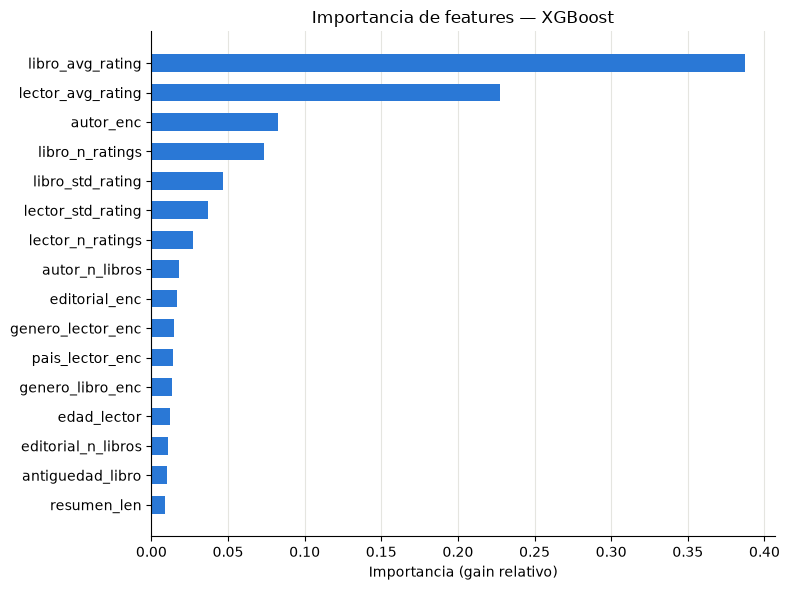

In [12]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index, importances.values, color="#2a78d6", height=0.6)
ax.set_xlabel("Importancia (gain relativo)")
ax.set_title("Importancia de features — XGBoost")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e5e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 7. Modelo final de producción

Ya validamos la metodología con un holdout honesto. Ahora recalculamos las estadísticas usando el **100% de las interacciones** y reentrenamos el modelo final con esos datos — este es el modelo que se usa para puntuar los pares (lector, libro) candidatos y generar las recomendaciones. Usar todos los datos disponibles para el modelo final (en vez de quedarnos con el modelo del 80%) es estándar: el holdout ya cumplió su propósito de estimar qué tan bien generaliza el enfoque.


In [13]:
full_stats = compute_stats(interacciones)
full_feat = build_features(interacciones, full_stats)
X_full, y_full = full_feat[FEATURE_COLS], full_feat["rating"]

final_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
t0 = time.time()
final_model.fit(X_full, y_full)
print(f"modelo final entrenado en {time.time() - t0:.1f}s sobre {len(X_full):,} interacciones")


modelo final entrenado en 2.1s sobre 461,074 interacciones


## 8. Generación de candidatos y Top-20 por lector

**Nota sobre libros con muy pocas calificaciones**: al probar el pipeline, notamos que los libros con **una sola** calificación (el 45% del pool de "libros con rating") terminaban dominando el top 20, incluso con el suavizado Bayesiano de la sección 4 — porque para esos libros, `libro_avg_rating`, `autor_enc`, `genero_libro_enc` y `editorial_enc` a menudo derivan casi todos de esa misma única observación, y el modelo (con 400 árboles) termina combinando varias señales correlacionadas que en el fondo son la misma evidencia débil repetida. La solución no es dejar de usar esos libros para *entrenar* (siguen aportando señal legítima al resto de las features, y las usamos igual), sino excluirlos del **pool de candidatos a recomendar**: pedimos un mínimo de `MIN_RATINGS_RECOMENDABLE = 5` calificaciones para que un libro sea elegible como recomendación. Quedan ~12.100 libros candidatos, más que suficientes para armar un top 20 confiable por lector.

Para los 832 lectores de `datos/ejemplo.csv` y esos libros candidatos, el cross-join da unos 10 millones de pares — lo procesamos igual **en lotes** (chunks) por prolijidad y para no acumular todo en memoria de una vez:

1. cross-join entre los lectores del lote y los libros candidatos,
2. le quitamos los pares que el lector ya calificó (anti-join contra `interacciones`),
3. predecimos el rating con el modelo final,
4. nos quedamos con el top 20 por lector del lote,

y acumulamos los resultados. Con lotes de 300 lectores esto tarda menos de un minuto en total.


In [14]:
BOOK_COLS = [
    "id_libro", "antiguedad_libro", "resumen_len", "autor_n_libros", "editorial_n_libros",
    "libro_avg_rating", "libro_n_ratings", "libro_std_rating", "genero_libro_enc", "autor_enc", "editorial_enc",
]
READER_COLS = [
    "id_lector", "edad_lector", "lector_avg_rating", "lector_n_ratings", "lector_std_rating",
    "genero_lector_enc", "pais_lector_enc",
]
gm = full_stats["global_mean"]

MIN_RATINGS_RECOMENDABLE = 5
libros_candidatos_ids = full_stats["libro_stats"].index[full_stats["libro_stats"]["libro_n_ratings"] >= MIN_RATINGS_RECOMENDABLE]
print(f"libros candidatos elegibles (>= {MIN_RATINGS_RECOMENDABLE} ratings): {len(libros_candidatos_ids):,} / {len(libros_con_rating_ids):,}")

book_feat_table = libros[libros["id_libro"].isin(libros_candidatos_ids)][
    ["id_libro", "titulo", "autor", "editorial", "genero_libro", "antiguedad_libro", "resumen_len",
     "autor_n_libros", "editorial_n_libros"]
].copy()
book_feat_table = book_feat_table.merge(full_stats["libro_stats"], on="id_libro", how="left")
book_feat_table = book_feat_table.merge(full_stats["genero_libro_enc"], on="genero_libro", how="left")
book_feat_table = book_feat_table.merge(full_stats["autor_enc"], on="autor", how="left")
book_feat_table = book_feat_table.merge(full_stats["editorial_enc"], on="editorial", how="left")
book_feat_table = book_feat_table.fillna({
    "libro_avg_rating": gm, "libro_n_ratings": 0, "libro_std_rating": 0,
    "genero_libro_enc": gm, "autor_enc": gm, "editorial_enc": gm,
    "autor_n_libros": 0, "editorial_n_libros": 0,
})

# left-join: los lectores de ejemplo.csv que no existen en `lectores` (p. ej. "alpasil") quedan con
# genero_lector/pais_lector/edad_lector en NaN, y sus features de historial caen al fallback (media global).
reader_feat_table = target_lectores.merge(
    lectores[["id_lector", "genero_lector", "pais_lector", "edad_lector"]], on="id_lector", how="left"
)
reader_feat_table = reader_feat_table.merge(full_stats["lector_stats"], on="id_lector", how="left")
reader_feat_table = reader_feat_table.merge(full_stats["genero_lector_enc"], on="genero_lector", how="left")
reader_feat_table = reader_feat_table.merge(full_stats["pais_lector_enc"], on="pais_lector", how="left")
reader_feat_table = reader_feat_table.fillna({
    "lector_avg_rating": gm, "lector_n_ratings": 0, "lector_std_rating": 0,
    "genero_lector_enc": gm, "pais_lector_enc": gm,
})

book_small = book_feat_table[BOOK_COLS].copy()
reader_small = reader_feat_table[READER_COLS].copy()
rated_pairs = interacciones[["id_lector", "id_libro"]]

print("book_small:", book_small.shape, " reader_small:", reader_small.shape)


libros candidatos elegibles (>= 5 ratings): 12,115 / 48,063
book_small: (12115, 11)  reader_small: (832, 7)


In [15]:
import gc

CHUNK_SIZE = 300
TOP_N = 20

all_reader_ids = reader_small["id_lector"].values
n_chunks = int(np.ceil(len(all_reader_ids) / CHUNK_SIZE))

results = []
t_start = time.time()

for i in range(n_chunks):
    batch_ids = all_reader_ids[i * CHUNK_SIZE:(i + 1) * CHUNK_SIZE]
    batch_readers = reader_small[reader_small["id_lector"].isin(batch_ids)]

    chunk = batch_readers.merge(book_small, how="cross")
    chunk = chunk.merge(rated_pairs, on=["id_lector", "id_libro"], how="left", indicator=True)
    chunk = chunk[chunk["_merge"] == "left_only"].drop(columns="_merge")

    chunk["pred_rating"] = final_model.predict(chunk[FEATURE_COLS])
    top_chunk = chunk.sort_values("pred_rating", ascending=False).groupby("id_lector").head(TOP_N)
    results.append(top_chunk[["id_lector", "id_libro", "pred_rating"]])

    del chunk, top_chunk, batch_readers
    gc.collect()

    if (i + 1) % 5 == 0 or i == n_chunks - 1:
        elapsed = time.time() - t_start
        print(f"lote {i + 1}/{n_chunks}  ({(i + 1) * CHUNK_SIZE} lectores procesados, {elapsed:.0f}s transcurridos)")

recomendaciones = pd.concat(results, ignore_index=True)
print(f"\nlisto en {time.time() - t_start:.0f}s — {len(recomendaciones):,} filas de recomendaciones")


lote 3/3  (900 lectores procesados, 7s transcurridos)

listo en 7s — 16,640 filas de recomendaciones


In [16]:
recomendaciones = recomendaciones.sort_values(["id_lector", "pred_rating"], ascending=[True, False])
recomendaciones["rank"] = recomendaciones.groupby("id_lector").cumcount() + 1

recomendaciones = recomendaciones.merge(
    libros[["id_libro", "titulo", "autor", "genero_libro"]], on="id_libro", how="left"
)
recomendaciones = recomendaciones.merge(
    lectores[["id_lector", "nombre"]], on="id_lector", how="left"
)
recomendaciones = recomendaciones[
    ["id_lector", "nombre", "rank", "id_libro", "titulo", "autor", "genero_libro", "pred_rating"]
]

print(f"lectores con recomendaciones: {recomendaciones['id_lector'].nunique():,}")
print(f"filas totales: {len(recomendaciones):,}  (esperado ~{len(reader_small) * TOP_N:,})")
recomendaciones.head(10)


lectores con recomendaciones: 832
filas totales: 16,640  (esperado ~16,640)


,id_lector,nombre,rank,id_libro,titulo,autor,genero_libro,pred_rating
0,05-03-1970,moses,1,promesas-de-sangre-las-lagrimas-de-kaiu-ii,PROMESAS DE SANGRE. Las lágrimas de Kaiu II,"ESPADA, DAVID y CUETO, MÓNICA","Fantástica, ciencia ficción",9.244086
1,05-03-1970,moses,2,el-aroma-de-los-mangos,EL AROMA DE LOS MANGOS,"AKAM, PAULO",Ficción literaria,9.233930
2,05-03-1970,moses,3,foe-el-misterio-del-halcon,FOE.. El misterio del halcón,"GARCÍA RODRÍGUEZ, ÁLVARO",Infantil y juvenil,9.188004
3,05-03-1970,moses,4,duelos-y-quebrantos,DUELOS Y QUEBRANTOS,"GIRÓN, ANA",Ficción literaria,9.165227
4,05-03-1970,moses,5,maestros-antiguos-comedia,MAESTROS ANTIGUOS: COMEDIA,"BERNHARD, THOMAS",Literatura contemporánea,9.135032
5,05-03-1970,moses,6,filippo-amor-reencarnado,FILIPPO: AMOR REENCARNADO,"LÓPEZ RODRÍGUEZ, DAVID","Fantástica, ciencia ficción",9.101031
6,05-03-1970,moses,7,el-tercer-encuentro,EL TERCER ENCUENTRO,"URDA ANGUITA, Mª ÁNGELES",Narrativa,9.096913
7,05-03-1970,moses,8,el-don-apacible-4-vols-,EL DON APACIBLE (4 VOLS.),"SHOLOJOV, MIJAIL",Clásicos de la literatura,9.078635
8,05-03-1970,moses,9,episodios-nacionales-quinta-serie,EPISODIOS NACIONALES. QUINTA SERIE,"PÉREZ GALDÓS, BENITO",Histórica y aventuras,9.070974
9,05-03-1970,moses,10,todo-paracuellos,TODO PARACUELLOS,"GIMÉNEZ GIMÉNEZ, CARLOS","Cómics, Novela Gráfica",9.020674


## 9. Ejemplos y guardado

Vemos el top 20 de un par de lectores concretos como chequeo de sanidad, y guardamos la tabla completa a CSV.


In [17]:
muestra_lectores = reader_small["id_lector"].sample(3, random_state=RANDOM_STATE).tolist()

for lector_id in muestra_lectores:
    nombre_match = lectores.loc[lectores["id_lector"] == lector_id, "nombre"]
    nombre = nombre_match.values[0] if len(nombre_match) else "(id no encontrado en lectores)"
    n_hist = int(reader_feat_table.loc[reader_feat_table["id_lector"] == lector_id, "lector_n_ratings"].values[0])
    print(f"\n=== Top 20 para '{nombre}' ({lector_id}) — {n_hist} libros ya calificados ===")
    display(recomendaciones[recomendaciones["id_lector"] == lector_id].drop(columns=["id_lector", "nombre"]))



=== Top 20 para 'oscar' (omallorqui) — 265 libros ya calificados ===


,rank,id_libro,titulo,autor,genero_libro,pred_rating
12200,1,el-aroma-de-los-mangos,EL AROMA DE LOS MANGOS,"AKAM, PAULO",Ficción literaria,9.630714
12201,2,promesas-de-sangre-las-lagrimas-de-kaiu-ii,PROMESAS DE SANGRE. Las lágrimas de Kaiu II,"ESPADA, DAVID y CUETO, MÓNICA","Fantástica, ciencia ficción",9.561838
12202,3,filippo-amor-reencarnado,FILIPPO: AMOR REENCARNADO,"LÓPEZ RODRÍGUEZ, DAVID","Fantástica, ciencia ficción",9.512613
12203,4,duelos-y-quebrantos,DUELOS Y QUEBRANTOS,"GIRÓN, ANA",Ficción literaria,9.508461
12204,5,foe-el-misterio-del-halcon,FOE.. El misterio del halcón,"GARCÍA RODRÍGUEZ, ÁLVARO",Infantil y juvenil,9.503867
12205,6,el-tercer-encuentro,EL TERCER ENCUENTRO,"URDA ANGUITA, Mª ÁNGELES",Narrativa,9.431663
12206,7,episodios-nacionales-quinta-serie,EPISODIOS NACIONALES. QUINTA SERIE,"PÉREZ GALDÓS, BENITO",Histórica y aventuras,9.366832
12207,8,el-nino-pajaro,EL NIÑO PÁJARO,"PEÑATE RODRÍGUEZ, JUAN MANUEL","Novela negra, intriga, terror",9.327365
12208,9,el-don-apacible-4-vols-,EL DON APACIBLE (4 VOLS.),"SHOLOJOV, MIJAIL",Clásicos de la literatura,9.326158
12209,10,maestros-antiguos-comedia,MAESTROS ANTIGUOS: COMEDIA,"BERNHARD, THOMAS",Literatura contemporánea,9.326079



=== Top 20 para 'xisca mas ortiz' (xisqui) — 80 libros ya calificados ===


,rank,id_libro,titulo,autor,genero_libro,pred_rating
16380,1,el-aroma-de-los-mangos,EL AROMA DE LOS MANGOS,"AKAM, PAULO",Ficción literaria,9.111767
16381,2,foe-el-misterio-del-halcon,FOE.. El misterio del halcón,"GARCÍA RODRÍGUEZ, ÁLVARO",Infantil y juvenil,8.986014
16382,3,filippo-amor-reencarnado,FILIPPO: AMOR REENCARNADO,"LÓPEZ RODRÍGUEZ, DAVID","Fantástica, ciencia ficción",8.972244
16383,4,promesas-de-sangre-las-lagrimas-de-kaiu-ii,PROMESAS DE SANGRE. Las lágrimas de Kaiu II,"ESPADA, DAVID y CUETO, MÓNICA","Fantástica, ciencia ficción",8.970940
16384,5,duelos-y-quebrantos,DUELOS Y QUEBRANTOS,"GIRÓN, ANA",Ficción literaria,8.942437
16385,6,el-tercer-encuentro,EL TERCER ENCUENTRO,"URDA ANGUITA, Mª ÁNGELES",Narrativa,8.874888
16386,7,maestros-antiguos-comedia,MAESTROS ANTIGUOS: COMEDIA,"BERNHARD, THOMAS",Literatura contemporánea,8.789873
16387,8,episodios-nacionales-quinta-serie,EPISODIOS NACIONALES. QUINTA SERIE,"PÉREZ GALDÓS, BENITO",Histórica y aventuras,8.759727
16388,9,el-don-apacible-4-vols-,EL DON APACIBLE (4 VOLS.),"SHOLOJOV, MIJAIL",Clásicos de la literatura,8.746022
16389,10,el-nino-pajaro,EL NIÑO PÁJARO,"PEÑATE RODRÍGUEZ, JUAN MANUEL","Novela negra, intriga, terror",8.737904



=== Top 20 para 'pepi' (gala) — 198 libros ya calificados ===


,rank,id_libro,titulo,autor,genero_libro,pred_rating
5800,1,el-aroma-de-los-mangos,EL AROMA DE LOS MANGOS,"AKAM, PAULO",Ficción literaria,9.445736
5801,2,promesas-de-sangre-las-lagrimas-de-kaiu-ii,PROMESAS DE SANGRE. Las lágrimas de Kaiu II,"ESPADA, DAVID y CUETO, MÓNICA","Fantástica, ciencia ficción",9.388343
5802,3,maestros-antiguos-comedia,MAESTROS ANTIGUOS: COMEDIA,"BERNHARD, THOMAS",Literatura contemporánea,9.365236
5803,4,foe-el-misterio-del-halcon,FOE.. El misterio del halcón,"GARCÍA RODRÍGUEZ, ÁLVARO",Infantil y juvenil,9.363078
5804,5,episodios-nacionales-quinta-serie,EPISODIOS NACIONALES. QUINTA SERIE,"PÉREZ GALDÓS, BENITO",Histórica y aventuras,9.334984
5805,6,duelos-y-quebrantos,DUELOS Y QUEBRANTOS,"GIRÓN, ANA",Ficción literaria,9.321451
5806,7,filippo-amor-reencarnado,FILIPPO: AMOR REENCARNADO,"LÓPEZ RODRÍGUEZ, DAVID","Fantástica, ciencia ficción",9.298115
5807,8,el-tercer-encuentro,EL TERCER ENCUENTRO,"URDA ANGUITA, Mª ÁNGELES",Narrativa,9.246543
5808,9,el-don-apacible-4-vols-,EL DON APACIBLE (4 VOLS.),"SHOLOJOV, MIJAIL",Clásicos de la literatura,9.204123
5809,10,los-siguientes,LOS SIGUIENTES,"SIMÓN, PEDRO",Narrativa,9.143699


In [18]:
output_path = "datos/recomendaciones_top20_ejemplo.csv"
recomendaciones.to_csv(output_path, index=False)
print(f"guardado en {output_path} ({len(recomendaciones):,} filas, {recomendaciones['id_lector'].nunique()} lectores)")


guardado en datos/recomendaciones_top20_ejemplo.csv (16,640 filas, 832 lectores)


## 10. Resumen y limitaciones

- El modelo (`XGBRegressor`, 400 árboles, profundidad 6) predice el rating 1-10 con el RMSE/MAE reportados en la sección 6, superando a los baselines de media global y promedio del libro.
- Las features más importantes son, por lejos, el rating promedio histórico del libro y del lector — esperable en un dataset de ratings explícitos con relativamente pocas features de contenido.
- El resultado final cubre los 832 lectores de `datos/ejemplo.csv`, incluyendo los 16 sin historial de calificaciones y el `id_lector` (`alpasil`) que no existe en `lectores` — todos reciben una predicción porque el modelo generaliza a partir de features, no de identidades de usuario.
- **Limitaciones / posibles mejoras futuras**:
  - Para lectores sin historial ni datos demográficos completos, la predicción se apoya solo en las features del libro (esencialmente "libros mejor valorados en general"), sin verdadera personalización.
  - No se usó el texto de `resumen` más allá de su longitud; embeddings de texto (p. ej. TF-IDF o un modelo de lenguaje) podrían capturar similitud de contenido entre libros.
  - El split train/test es aleatorio, no temporal; una validación con corte por fecha sería más realista para un escenario de producción real.
  - No se ajustaron hiperparámetros con validación cruzada — hay margen para mejorar el RMSE con una búsqueda más sistemática (grid/random/Bayesian search).
  - Un enfoque híbrido con filtrado colaborativo (p. ej. factorización matricial) podría complementar las features basadas en agregados y encoding usadas acá, sobre todo para lectores con historial rico.
